## Исследование данных о российском кинопрокате



Заказчик этого исследования — Министерство культуры Российской Федерации. 

Необходимо изучить рынок российского кинопроката и выявить текущие тренды. Необходимо уделить внимание фильмам, которые получили государственную поддержку. Попробуем ответить на вопрос, насколько такие фильмы интересны зрителю. 

Мы будем работать с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск. 

### Шаг 1. Откройте файлы с данными и объедините их в один датафрейм. 

Объедините данные таким образом, чтобы все объекты из датасета `mkrf_movies` обязательно вошли в получившийся датафрейм. 

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_0" aria-expanded="false" aria-controls="collapseHint_0">Подсказка</button>
        </div>
        <div id="collapseHint_0" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Обратите внимание на тип данных столбца, по которому будете соединять датафреймы. Тип данных этих столбцов должен быть одинаковым в обоих датафреймах.
            </div>
        </div>
    </div>
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# from ydata_profiling import ProfileReport
pd.set_option('display.float_format', '{:,.2f}'.format)


In [2]:
# Создаем два DataFrame для двух соответствующих таблиц

try:
    data = pd.read_csv('mkrf_movies.csv')
    data_f = pd.read_csv('mkrf_shows.csv')
except:
    data = pd.read_csv('/datasets/mkrf_movies.csv')
    data_f = pd.read_csv('/datasets/mkrf_shows.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [4]:
data.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [5]:
data_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


In [6]:
data_f.head(10)

,puNumber,box_office
0,111000113,"2,450.00"
1,111000115,"61,040.00"
2,111000116,"153,030,013.40"
3,111000117,"12,260,956.00"
4,111000118,"163,684,057.79"
5,111000119,"4,293,649.51"
6,111000212,200.00
7,111000216,"355,567.00"
8,111000313,710.00
9,111000314,"1,607,970.00"


In [7]:
data['puNumber'] = data['puNumber'].replace('нет', '0').astype('int')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int64  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [8]:
data = data.join(data_f.set_index('puNumber'), on='puNumber')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int64  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

### Шаг 2. Предобработка данных

#### Шаг 2.1. Проверьте типы данных

- Проверьте типы данных в датафрейме и преобразуйте их там, где это необходимо.

Проверим типы данных для столбцов с float64, возможно это избыточно.
Так и есть. Для всех текущих столбцов c float избыточно считать копейки, но переводить в int пока не будем, так как там есть пропущенные значения типа NaN, которых в типе данных int нет.

Переведем столбец show_start_date в datetime

In [10]:
data.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [11]:
data['show_start_date'] = pd.to_datetime(data['show_start_date'],
                                              format='%Y-%m-%dT%H:%M:%S.%fZ')
data.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


Переведем тип данных столбца ratings в float

In [12]:
data['ratings'] = data['ratings'].str.replace('%', '')

In [13]:
data['ratings'] = pd.to_numeric(data['ratings'])

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7468 non-null   object        
 5   production_country     7484 non-null   object        
 6   director               7477 non-null   object        
 7   producer               6918 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 332 non-null    float64       
 12  financing_source       332 non-null    object        
 13  rat

##### Результат изменения типов данных
Тип данных столбца show_start_date переведен в datetime, столбца ratings переведен в float

#### Шаг 2.2. Изучите пропуски в датафрейме

- Объясните, почему заполнили пропуски определённым образом или почему не стали этого делать.

Для присоединения данных о сборах были заменены значения puNumber с "нет" на 0.


In [15]:
data.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                   967
genres                    976
box_office               4328
dtype: int64

##### Результаты изучения пропуска в данных
Имеются незначительные пропуски в категориальных столбцах (поэтому их невозможно воостановить), которые не повлияют на результаты исследования:
- film_studio
- production_country
- director
- producer
- genres

Имеются незначительные пропуски в количественных столбцах, которые не повлияют на результаты исследования. При изменении отсутствующих значений на 0, есть вероятность в дальнейшем получить ошибки:
- ratings

Значительное и одинаковое отсутствие данных о господдержке, которые восстановить нет возможности. Что не помешает изучить датасет, поэтому удаляться не будут:
- refundable_support
- nonrefundable_support
- financing_source

В budget отутствуют данные, но при изучении фильмов с господдержкой, можно будет восполнить с помощью суммы господдержки

В box_office имеется значительное отсутсвие данных, но заполнить эти данные не имеется возможности из-за невозможности предсказания результатов сборов, поэтому остаются без изменений:


#### Шаг 2.3. Изучите дубликаты в датафрейме
- Проверьте, есть ли в данных дубликаты. Опишите причины, которые могли повлиять на появление дублей.

In [16]:
data.duplicated().sum()

0

In [17]:
data[data['puNumber'].duplicated()]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4639,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17 12:00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.60,"драма,мелодрама,история",NaN
5068,Анализируй то!,221054410,2010-05-25 12:00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.80,"комедия,криминал",NaN


In [18]:
data[data['title'].duplicated()]['title'].count()

714

In [19]:
data[data['title'] == 'Робин Гуд (Robin Hood)']

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
338,Робин Гуд (Robin Hood),221027016,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Имэджин Интертейнмент, Риле...",Великобритания - США,Ридли Скотт,"Брайан Грейзер, Рассел Кроу, Ридли Скотт",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.20,"боевик,драма,приключения",NaN
4274,Робин Гуд (Robin Hood),121007810,2010-04-23 12:00:00,Художественный,"Юниверсал Пикчерз, Имэджин Интертейнмент, Риле...",Великобритания - США,Ридли Скотт,"Брайан Грейзер, Рассел Кроу, Ридли Скотт",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.20,"боевик,драма,приключения","2,650.00"
4364,Робин Гуд (Robin Hood),221115710,2010-10-07 12:00:00,Художественный,"Юниверсал Пикчерз, Имэджин Интертейнмент, Риле...",Великобритания - США,Ридли Скотт,"Брайан Грейзер, Рассел Кроу, Ридли Скотт",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.20,"боевик,драма,приключения",NaN
5307,Робин Гуд (Robin Hood),221086210,2010-08-16 12:00:00,Художественный,"Юниверсал Пикчерз, Имэджин Интертейнмент, Риле...",Великобритания - США,Ридли Скотт,"Брайан Грейзер, Рассел Кроу, Ридли Скотт",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.20,"боевик,драма,приключения",NaN


In [20]:
data.groupby('title').head(2)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.20,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.60,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.70,драма,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7481,Сад художника: Американский импрессионизм,126008019,2019-12-23 12:00:00,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7482,Звериная ярость,121037819,2019-12-24 12:00:00,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.40,"боевик,триллер",NaN
7483,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28 12:00:00,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7484,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30 12:00:00,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Дубликаты присутствуют, но они скрыты за названиями, имеют разные прокатные удостоверения и даты проката. Поэтому сгруппируем данные по названию и выполним agg со словарем, чтобы избавиться от дубликатов и при этом учесть дату выхода, сборы рейтинг фильма, бюджет

In [21]:
data = data.groupby('title', as_index=False).agg({'puNumber':'first',
                                          'show_start_date':'min',
                                          'type':'first',
                                          'film_studio':'first',
                                          'production_country':'first',
                                          'director':'first',
                                          'producer':'first',
                                          'age_restriction':'first',
                                          'refundable_support':'max',
                                          'nonrefundable_support':'max',
                                          'budget':'max',
                                          'financing_source':'first',
                                          'ratings':'first',
                                          'genres':'first',
                                          'box_office':'sum',
                                          })
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6772 entries, 0 to 6771
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  6772 non-null   object        
 1   puNumber               6772 non-null   int64         
 2   show_start_date        6772 non-null   datetime64[ns]
 3   type                   6772 non-null   object        
 4   film_studio            6755 non-null   object        
 5   production_country     6770 non-null   object        
 6   director               6763 non-null   object        
 7   producer               6218 non-null   object        
 8   age_restriction        6772 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 332 non-null    float64       
 12  financing_source       332 non-null    object        
 13  rat

##### Результат изучения дубликатов
Дубликаты были скрыты за названиями, имели разные прокатные удостоверения и даты проката. Поэтому данные были сгруппированы по названию с учетом даты выхода, сборов, рейтинга фильма и бюджета

Были удалены дубликаты фильмов по одниковому названию

#### Шаг 2.4. Изучите категориальные значения

- Посмотрите, какая общая проблема встречается почти во всех категориальных столбцах;
- Исправьте проблемные значения в поле `type`.

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_1" aria-expanded="false" aria-controls="collapseHint_1">Подсказка</button>
        </div>
        <div id="collapseHint_1" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
В поле <code>type</code> есть несколько значений, у которых появился пробел в начале строки. Самый простой способ их «починить» -- использовать метод <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html#pandas.Series.str.strip">.str.strip</a>. Этот метод удаляет все пробелы, которые встречаются в начале и в конце строки. Применяют его таким образом:<br>
<code>data['type'].str.strip()</code>
            </div>
        </div>
    </div>
</div>

In [22]:
data['type'].value_counts()

Художественный                3930
 Художественный               1350
Анимационный                   766
Прочие                         390
Документальный                 282
Научно-популярный               52
Музыкально-развлекательный       1
 Анимационный                    1
Name: type, dtype: int64

In [23]:
data['production_country'].unique()

array(['Индия', 'СССР', 'США - Германия - Великобритания', 'Россия',
       'Республика Кипр-Россия', 'США', 'Республика Кипр, США, Россия',
       'Франция', 'США - Великобритания', 'Аргентина', 'Испания - США',
       'Австралия', 'Германия',
       'Франция-Грузия-Германия-Россия-Украина-Бельгия',
       'Польша - Ирландия', 'США - Испания', 'США-Великобритания',
       'Великобритания - Франция - США', 'Япония-Великобритания',
       'Франция-Канада', 'Франция - Великобритания', 'Великобритания',
       'Германия - Швейцария', 'США - ЮАР - Гонконг', 'США - Австралия',
       'Германия - Австрия - Франция', 'Франция - Германия - Бельгия',
       'Канада', 'Республика Корея', 'Россия - Германия - Украина',
       'Италия', 'США - Швейцария - Франция',
       'Великобритания, Новая Зеландия', 'Великобритания-США', 'Испания',
       'Парагвай', 'Италия - Франция', 'Казахстан', 'США - Финляндия',
       'Испания - Швейцария - Великобритания - Германия - Новая Зеландия - Нидерланды - Кан

In [24]:
data['genres'].value_counts()

драма                           448
комедия                         329
мелодрама,комедия               181
драма,мелодрама                 170
драма,мелодрама,комедия         167
                               ... 
детектив,история,драма            1
мультфильм,приключения,драма      1
ужасы,мелодрама,комедия           1
мелодрама,история,драма           1
фэнтези,ужасы,триллер             1
Name: genres, Length: 742, dtype: int64

Предварительный анализ выявил проблем в категориальных данных пробелы и разделители. Удалим случайные пробелы из начала и конца строк и из средин строк между разделителями. Другими словами удалим все пробелы. 

In [25]:
for col in ['title', 'type', 'film_studio', 'production_country',
            'director', 'producer',
            'financing_source', 'genres']:
    data[col] = data[col].str.replace(' ','')
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6772 entries, 0 to 6771
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  6772 non-null   object        
 1   puNumber               6772 non-null   int64         
 2   show_start_date        6772 non-null   datetime64[ns]
 3   type                   6772 non-null   object        
 4   film_studio            6755 non-null   object        
 5   production_country     6770 non-null   object        
 6   director               6763 non-null   object        
 7   producer               6218 non-null   object        
 8   age_restriction        6772 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 332 non-null    float64       
 12  financing_source       332 non-null    object        
 13  rat

In [26]:
data['type'].value_counts()

Художественный                5280
Анимационный                   767
Прочие                         390
Документальный                 282
Научно-популярный               52
Музыкально-развлекательный       1
Name: type, dtype: int64

##### Результат изучения категориальных данных
Предварительный анализ выявил проблем в категориальных данных пробелы и разделители. Были удалены как случайные пробелы, так и намереные, теперь нет ситуаций "разделитель и пробел" и просто "разделитель" между данными.

#### Шаг 2.5. Проверьте количественные значения

- Проверьте, обнаружились ли в таких столбцах подозрительные данные. Как с такими данными лучше поступить?

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_budget" aria-expanded="false" aria-controls="collapseHint_budget">Подсказка</button>
        </div>
        <div id="collapseHint_budget" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Обратите внимание на описание столбца <code>budget</code>. Как этот столбец соотносится с двумя другими: <code>refundable_support</code> и <code>nonrefundable_support</code>?
            </div>
        </div>
    </div>
</div>

Изучим и откорректируем стобец budget

In [27]:
data['budget'].value_counts().sort_index()

0.00                17
14,462,464.00        1
15,010,000.00        1
18,166,418.00        1
18,706,080.00        1
                    ..
779,941,965.00       1
944,000,000.00       1
980,000,000.00       1
1,032,905,957.00     1
2,305,074,303.00     1
Name: budget, Length: 290, dtype: int64

In [28]:
data[data['budget'] == 0].head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
53,14+,111023614,2014-12-19 12:00:00,Художественный,"ОООКиностудия""Сентябрь""",Россия,А.Зайцев,"О.Гранина,А.Зайцев",«16+» - для детей старше 16 лет,0.00,"23,000,000.00",0.00,"Министерствокультуры,Фондкино",6.60,мелодрама,"10,234,016.10"
478,БабаЯга,114006518,2018-11-08 12:00:00,Анимационный,"ООО""АртПикчерсСтудия""",Россия,В.Саков,"ООО""АртПикчерсСтудия"",ООО""КРИЭЙТИВАНИМЭЙШН"",ОО...",«6+» - для детей старше 6 лет,0.00,"138,969,465.00",0.00,Фондкино,NaN,None,"1,334,699.40"
518,Бармен.,111009615,2015-05-26 12:00:00,Художественный,"АО""ВайТМедиа"",ООО""АртПикчерсСтудия""",Россия,Д.Штурманова,Т.Вайнштейн,«16+» - для детей старше 16 лет,"20,000,000.00",0.00,0.00,Фондкино,6.20,"комедия,фэнтези","67,418,974.80"
705,Большоепутешествие,114002419,2019-04-20 12:00:00,Анимационный,"ООО""ЛИЦЕНЗИОННЫЕБРЕНДЫ""",Россия,"Н.Лопато,В.Ровенский","ООО""ЛИЦЕНЗИОННЫЕБРЕНДЫ""",«6+» - для детей старше 6 лет,"60,000,000.00","120,000,000.00",0.00,Фондкино,6.20,"мультфильм,комедия,приключения","147,606,826.51"
1025,Воин(2015),111017315,2015-09-28 12:00:00,Художественный,"ООО""ФорпостПродакшн"",ООО""АртПикчерсСтудия""",Россия,А.Андрианов,"ООО""АртПикчерсСтудия""",«12+» - для детей старше 12 лет,"10,000,000.00","70,000,000.00",0.00,Фондкино,7.80,"боевик,драма,криминал","196,572,438.40"


In [29]:
data[(data['budget'].isna()) & (~data['financing_source'].isna())].shape[0]

0

In [30]:
data[data['budget'] == 0].shape[0] / data[~(data['refundable_support'].isna()) | (~data['nonrefundable_support'].isna())].shape[0] * 100


5.120481927710843

Чтобы не удалаять 5% данных о фильмах с госбюджетом, посчитали их бюджет как сумму поддержки и внесли изменения в данные

In [31]:
data.loc[data['budget'] == 0, 'budget'] = data['refundable_support'] + data['nonrefundable_support']
data[data['budget'] == 0].shape[0]

0

Откорректируем столбец ratings, чтобы все значения были в промежутке от 0 до 10

In [32]:
data['ratings'] = data['ratings'].where(data['ratings'] <= 10, data['ratings']/10)

In [33]:
data['ratings'].max()

9.9

In [34]:
data['ratings'].min()

1.0

##### Результат проверки количественных значений
Проанализировав столбец бюджет выяснилось, что только у 17 фильмов с господдержкой отсутствует бюджет. Чтобы не удалаять 5% данных о фильмах с госбюджетом, посчитали их бюджет как сумму поддержки и внесли изменения в данные. Также откорректировали значения столбца ratings.

#### Шаг 2.6. Добавьте новые столбцы





- Создайте столбец с информацией о годе проката. Выделите год из даты премьеры фильма.

In [35]:
data['show_start_date_year'] = data['show_start_date'].dt.year
data['show_start_date_year']

0       2018
1       2014
2       2010
3       2019
4       2015
        ... 
6767    2019
6768    2010
6769    2014
6770    2018
6771    2012
Name: show_start_date_year, Length: 6772, dtype: int64

- Создайте два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно.

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_2" aria-expanded="false" aria-controls="collapseHint_2">Подсказка</button>
        </div>
        <div id="collapseHint_2" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Чтобы создать такие столбцы, лучше всего использовать собственную функцию. Эту функцию можно применить к двум столбцам сразу. 
            </div>
        </div>
    </div>
</div>

In [36]:
def mainer(row):
    if ',' in str(row):
        return row.split(',')[0]
    else:
        return row

In [37]:
data['director_main'] = data['director'].apply(mainer)
data['genres_main'] = data['genres'].apply(mainer)
data.head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,show_start_date_year,director_main,genres_main
0,ЯПРЕПОД,121019018,2018-09-06 12:00:00,Художественный,ЯшРаджФилмз,Индия,СиддхартхМалхотра,МанешШарма,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,7.80,"драма,комедия","145,448.00",2018,СиддхартхМалхотра,драма
1,"""SOS""надтайгой",111021114,2014-12-01 12:00:00,Художественный,"Киностудия""Мосфильм""",СССР,"В.Перов,А.Кольцатый",None,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,6.70,"драма,криминал,приключения",0.00,2014,В.Перов,драма
2,"""V""значитвендетта",221167310,2010-12-25 12:00:00,Художественный,"УорнерБразерс,СильверПикчерз,АнархозПродакшнз,...",США-Германия-Великобритания,ДжеймсМакТэйг,"ЛарриВачовски,ЭндиВачовски,ДжоэлСильвер,ГрантХилл",«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,7.80,"фантастика,боевик,триллер",0.00,2010,ДжеймсМакТэйг,фантастика
3,"""АРТиШОК""анимационныйальманахавторскихфильмов",114001719,2019-03-07 12:00:00,Анимационный,"ООО""Студия""Пчела""",Россия,"Д.Великовская,Н.Лопато(псевдонимНилова)","В.Гассиев,Ф.Пролиг",«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,NaN,None,0.00,2019,Д.Великовская,None
4,"""Бежинлуг""СергеяЭйзенштейна",112000115,2015-04-23 12:00:00,Документальный,"Киностудия""Мосфильм""",СССР,С.Эйзенштейна,None,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,NaN,None,0.00,2015,С.Эйзенштейна,None
5,"""Державная""Размышления100летспустя",112000518,2018-06-07 12:00:00,Документальный,"АО""АМАЛЬГАМАСТУДИЯ""",Россия,Д.Алейников,"С.Новиков,А.Феофанов",«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,NaN,None,0.00,2018,Д.Алейников,None
6,"""Зеленоеяблоко""анимационныйальманахвыпуск№7",114001819,2019-03-08 12:00:00,Анимационный,"ООО""Студия""Пчела""",Россия,"С.Андрианова,А.Чижикова(псевдонимА.Воронина),П...",В.Гассиев,«6+» - для детей старше 6 лет,NaN,NaN,NaN,None,NaN,None,0.00,2019,С.Андрианова,None
7,"""Машиныпесенки"".Серия""ОпятьНовыйГод!""",114004519,2019-11-15 12:00:00,Анимационный,"АнимаккордЛтд,ОООСтудия""АНИМАККОРД""",РеспубликаКипр-Россия,РоманКозич,ДмитрийЛовейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,5.90,"короткометражка,драма,триллер",0.00,2019,РоманКозич,короткометражка
8,"""Море""",111000913,2013-03-13 12:00:00,Художественный,"ООО""ТПО""РОК"",ООО""Коломна""",Россия,А.Стреляная,А.Учитель,«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,6.10,"триллер,драма,детектив",0.00,2013,А.Стреляная,триллер
9,"""Сезондождей"",""ДиетаМатроскина"",""Шарикхочеттел...",114000819,2019-02-15 12:00:00,Анимационный,"ФГУП""ТПО""Киностудия""Союзмультфильм""",Россия,"Е.Жиркова,А.Кузина,М.Солошенко","Б.Машковцев,Л.Бланк,И.Ковалев",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,NaN,None,0.00,2019,Е.Жиркова,None


- Посчитайте, какую долю от общего бюджета фильма составляет государственная поддержка.

In [38]:
data['state_support_part'] = round((data['refundable_support'] + data['nonrefundable_support']) / data['budget'], 3)
data[~data['budget'].isna()]['state_support_part'].head(5)

19   0.67
44   0.22
53   1.00
75   0.35
84   0.51
Name: state_support_part, dtype: float64

- Категоризируем рейтинг фильмов на 10 частей

In [39]:
data['ratings_category'] = data['ratings'] // 1

##### Результат добавления новых столбоцов
Были добавлены новые столбцы:
- год проката
- имя главного режиссера
- главный жанр
- доля госбюджета от общего бюджета
- категоризированный рейтинг

### Шаг 3. Проведите исследовательский анализ данных


#### Cколько фильмов выходило в прокат каждый год
- Посмотрим, сколько фильмов выходило в прокат каждый год. Обратим внимание, что данные о прокате в кинотеатрах известны не для всех фильмов. Посчитаем, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируем, как эта доля менялась по годам. Сделаем вывод о том, какой период полнее всего представлен в данных.

In [40]:
data[data['box_office'] > 0].groupby(by='show_start_date_year')['title'].count()

show_start_date_year
2010    107
2011    107
2012    124
2013    180
2014    271
2015    461
2016    502
2017    355
2018    474
2019    523
Name: title, dtype: int64

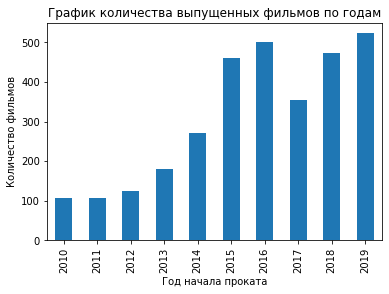

In [95]:
data[data['box_office'] > 0].groupby(by='show_start_date_year')['title'].count().plot(kind='bar',
                                                              title='График количества выпущенных фильмов по годам', 
                                                              xlabel='Год начала проката', 
                                                              ylabel='Количество фильмов');

In [42]:
data[~data['show_start_date_year'].isna()].shape[0]


6772

In [43]:
data[data['show_start_date'].isna()].shape[0]

0

In [44]:
data[data['show_start_date'] == 0].shape[0]

0

In [45]:
data.shape[0]

6772

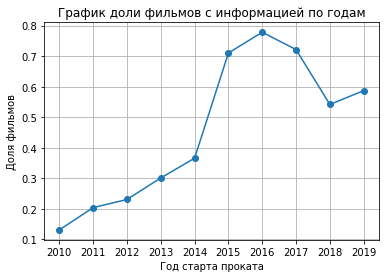

In [97]:
(data[data['box_office'] > 0].groupby(by='show_start_date_year')['title'].count() / 
data.groupby(by='show_start_date_year')['title'].count()).plot(marker='o',
                                                              grid=True,
                                                              xticks=range(2010,2020),
                                                              xlabel='Год старта проката',
                                                              ylabel='Доля фильмов',
                                                              title='График доли фильмов c информацией по годам');

##### Результат исследования количества фильмов по годам


Больше всего фильмов вышло в 2019 году - 523 фильма, меньше всего в 2010, 2011 - по 107 фильма. Наиболее полно представлен 2016 год, в котором вышло 502 фильма.

#### Изучите, как менялась динамика проката по годам. 
В каком году сумма сборов была минимальной? А максимальной?

In [47]:
data.groupby(by='show_start_date_year')['box_office'].sum()

show_start_date_year
2010       17,211,707.97
2011       29,122,384.01
2012        7,003,393.00
2013       29,823,546.20
2014    7,452,904,710.70
2015   39,498,203,154.90
2016   47,860,633,101.41
2017   48,559,032,092.51
2018   49,654,129,655.82
2019   48,411,658,730.61
Name: box_office, dtype: float64

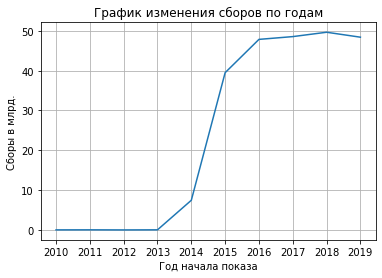

In [48]:
(data.groupby(by='show_start_date_year')['box_office'].sum()/1000000000).plot(grid=True,
                                                                             xticks=range(2010,2020),
                                                                             xlabel='Год начала показа',
                                                                             ylabel='Сборы в млрд.',
                                                                             title='График изменения сборов по годам');

In [49]:
print('Минимальная сумма сборов в 2012 году:', round(data.groupby(by='show_start_date_year')['box_office'].sum().min(),2))
print('Максимальная сумма сборов в 2018 году:', round(data.groupby(by='show_start_date_year')['box_office'].sum().max(),2))

Минимальная сумма сборов в 2012 году: 7003393.0
Максимальная сумма сборов в 2018 году: 49654129655.82


##### Результаты изучения динамики проката по годам

С 2014 года наблюдается резкое увеличение сборов. При этом минимальная сумма сборов в 2012 году - 7,003,393.0, а максимальная сумма сборов в 2018 году - 49,654,129,655.82.
Данное наблюдение могло возникнуть из-за изменения курса валюты в 2014 году и более качественного сбора информации о прокате.

#### Изучим cреднюю и медианную сумма сборов для каждого года
С помощью сводной таблицы посчитаем среднюю и медианную сумму сборов для каждого года.

In [50]:
data[~data['box_office'].isna()].groupby(by='show_start_date_year')['box_office'].agg(['mean', 'median'])

,mean,median
show_start_date_year,,
2010,"21,041.21",0.00
2011,"55,471.21",0.00
2012,"13,017.46",0.00
2013,"49,872.15",0.00
2014,"10,057,901.09",0.00
2015,"60,860,097.31","1,171,189.00"
2016,"74,202,531.94","1,680,265.85"
2017,"98,697,219.70","3,044,403.00"
2018,"56,747,576.75","387,247.00"


Максимальная средняя сумма сборов в 2017 году - 98 697 220, медиана - 3 044 403

#### Изучим влияние возрастного ограничения на сборы
Определим, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Определим фильмы с каким возрастным ограничением собрали больше всего денег в прокате. Меняется ли картина в зависимости от года? Если да, предположим, с чем это может быть связано.

In [51]:
data[data['show_start_date_year'] >= 2015].pivot_table(index='show_start_date_year', columns='age_restriction', values='box_office')

age_restriction,«0+» - для любой зрительской аудитории,«12+» - для детей старше 12 лет,«16+» - для детей старше 16 лет,«18+» - запрещено для детей,«6+» - для детей старше 6 лет
show_start_date_year,,,,,
2015,"8,064,993.80","102,376,556.46","49,430,249.13","33,327,052.56","114,497,362.78"
2016,"2,383,861.88","99,995,041.09","82,903,103.94","39,271,233.69","140,158,226.40"
2017,"5,339,510.00","115,462,171.48","126,624,106.59","57,793,386.71","183,123,365.84"
2018,"421,415.61","60,711,879.41","71,137,428.55","40,301,985.92","88,640,128.28"
2019,"243,096.81","66,023,717.15","49,614,011.88","41,621,437.31","102,004,354.37"


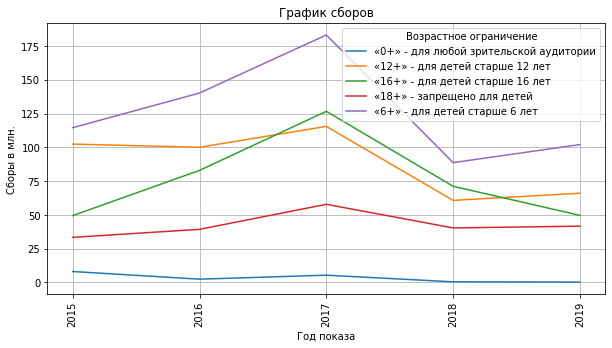

In [52]:
(data[data['show_start_date_year'] >= 2015].pivot_table(index='show_start_date_year', columns='age_restriction', values='box_office').round(0)/1000000).plot(grid=True, 
                                                                                                                                                   rot=90,
                                                                                                                                                   ylabel='Сборы в млн.',
                                                                                                                                                   figsize=(10,5),
                                                                                                                                                   xticks=[2015,2016,2017,2018,2019],
                                                                                                                                                   xlabel='Год показа',
                                                                                                                                                   title='График сборов');
plt.legend(title='Возрастное ограничение');

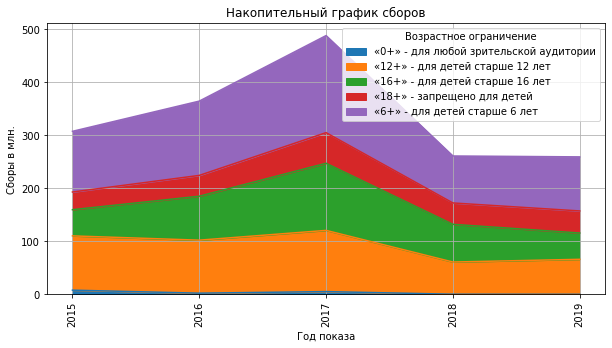

In [53]:
(data[data['show_start_date_year'] >= 2015].pivot_table(index='show_start_date_year', columns='age_restriction', values='box_office').round(0)/1000000).plot(kind='area',
                                                                                                                                                    grid=True, 
                                                                                                                                                   rot=90,
                                                                                                                                                   ylabel='Сборы в млн.',
                                                                                                                                                   figsize=(10,5),
                                                                                                                                                   xticks=[2015,2016,2017,2018,2019],
                                                                                                                                                   xlabel='Год показа',
                                                                                                                                                   title='Накопительный график сборов');
plt.legend(title='Возрастное ограничение');

##### Предварительный вывод
Возрастное ограничение аудитории влияет на сборы фильма в прокате. Наиболее кассовыми являются фильмы с рейтингом 6+, а наименее кассовыми с рейтингом 0+. В зависимости от года картина по показателям для разных ограничений существенно не изменяется, но изменяется общая сумма кассовых сборов.

### Шаг 4. Исследуйте фильмы, которые получили государственную поддержку

На этом этапе нет конкретных инструкций и заданий — поищите интересные закономерности в данных. Посмотрите, сколько выделяют средств на поддержку кино. Проверьте, хорошо ли окупаются такие фильмы, какой у них рейтинг.

In [54]:
data_support = data[(data['refundable_support'] > 0) | (data['nonrefundable_support'] > 0)]
data_support.loc[:,'all_support'] = data['refundable_support'] + data['nonrefundable_support']
data_support.loc[:,'сoefficient_profit'] = round(data['box_office'] / data['budget'], 2)
data_support

/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,ratings,genres,box_office,show_start_date_year,director_main,genres_main,state_support_part,ratings_category,all_support,сoefficient_profit
19,(Не)идеальныймужчина,111023119,2019-12-24 12:00:00,Художественный,"ООО""Нон-СтопПродакшн""",Россия,М.Бальчюнас(псевдонимМ.Вайсберг),"С.Мелькумов,А.Роднянский,М.Вайсберг,Р.Минасбекян",«12+» - для детей старше 12 лет,"40,000,000.00",...,4.50,"комедия,фантастика,мелодрама",0.00,2019,М.Бальчюнас(псевдонимМ.Вайсберг),комедия,0.67,4.00,"100,000,000.00",0.00
44,12месяцев.Новаясказка,111014414,2014-10-16 12:00:00,Художественный,"ООО""Киностудия""Никола-фильм"",ООО""ИнвестментБиз...",Россия,Д.Елеонский,И.Каленов,«0+» - для любой зрительской аудитории,"15,000,000.00",...,3.80,"семейный,фэнтези","32,244,810.00",2014,Д.Елеонский,семейный,0.22,3.00,"20,000,000.00",0.36
53,14+,111023614,2014-12-19 12:00:00,Художественный,"ОООКиностудия""Сентябрь""",Россия,А.Зайцев,"О.Гранина,А.Зайцев",«16+» - для детей старше 16 лет,0.00,...,6.60,мелодрама,"10,234,016.10",2014,А.Зайцев,мелодрама,1.00,6.00,"23,000,000.00",0.44
75,28Панфиловцев,111000916,2016-01-27 12:00:00,Художественный,ИндивидуальныйПредпринимательШальопаА.Г.,Россия,"К.Дружинин,А.Шальопа",А.Шальопа,«12+» - для детей старше 12 лет,0.00,...,7.50,"военный,драма,история","363,622,804.90",2016,К.Дружинин,военный,0.35,7.00,"30,000,000.00",4.26
84,30свиданий,111020815,2015-12-10 12:00:00,Художественный,"ООО""ИнспирейшнФилмс""",Россия,Т.Игуменцева,"Д.Литвинов,Д.Осмеркин,А.Гавриш,А.Агеев",«16+» - для детей старше 16 лет,"5,000,000.00",...,5.30,"комедия,мелодрама","85,405,423.61",2015,Т.Игуменцева,комедия,0.51,5.00,"25,000,000.00",1.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6741,Ясвободен,111023019,2019-12-26 12:00:00,Художественный,"АО""ТПО""Киностудияим.М.Горького""",Россия,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,0.00,...,5.90,драма,0.00,2019,И.Северов,драма,0.65,5.00,"30,000,000.00",0.00
6749,Яумеювязать,111019615,2015-11-27 12:00:00,Художественный,"ООО""БелоеЗеркало""",Россия,Н.СтепановаприучастииС.Иванова,"С.Кикнавелидзе,Д.Улюкаев",«16+» - для детей старше 16 лет,0.00,...,9.00,драма,"801,370.00",2015,Н.СтепановаприучастииС.Иванова,драма,0.33,9.00,"4,700,000.00",0.06
6752,Яхудею,111001618,2018-03-07 12:00:00,Художественный,"ООО""ДругДруга"",ООО""ДиПиДжи""",Россия,А.Черномазов(псевдонимАлексейНужный),"С.Корнихин,Н.Куликов,А.Черномазов,А.Кремер,Е.К...",«16+» - для детей старше 16 лет,0.00,...,6.90,комедия,"633,462,266.74",2018,А.Черномазов(псевдонимАлексейНужный),комедия,0.34,6.00,"30,000,000.00",7.23
6759,Я-Учитель,111019715,2015-12-02 12:00:00,Художественный,"НПКиностудиядетскихиюношескихфильмов""ИльяМуромец""",Россия,С.Мокрицкий,А.Ковтунец,«12+» - для детей старше 12 лет,0.00,...,7.40,"мелодрама,комедия","1,550.00",2015,С.Мокрицкий,мелодрама,0.39,7.00,"35,000,000.00",0.00


In [74]:
def pivot_group(df, group, head=0, pl=False, rt=0, kn='line', lc=0, x='', title='',xt=[], sort='box_office'):

    out = df.pivot_table(
        index=group,values=['box_office',
        'budget',
        'all_support',
        'nonrefundable_support',
        'refundable_support',
        'state_support_part',
        'сoefficient_profit'],
        aggfunc={'box_office':'sum',
                 'budget':'sum',
                 'all_support':'sum',
                 'nonrefundable_support':'sum',
                 'refundable_support':'sum',
                 'state_support_part':'mean',
                 'сoefficient_profit':'mean'}
        ).sort_values(sort, ascending=False)
    out.columns=['Господдержка','Сборы', 'Бюджет', 'Невозвращаемая поддержка', 'Возвращаемая поддержка', 'Доля господдержки', 'Окупаемость']
    if head > 0:
        out = out.head(head)
    
    display(out);
    if pl:
        if lc > 0:
            display((out.iloc[:lc,:-2] / 1000000).plot(ylabel='млн. руб.',
                                     rot=rt,
                                     kind=kn,
                                     grid=True,
                                     xlabel=x,
                                     title=title));
        else:    
            display((out.iloc[:,:-2] / 1000000).plot(ylabel='млн. руб.',
                                     rot=rt,
                                     kind=kn,
                                     grid=True,
                                     xlabel=x,
                                     title=title));

#### Изучим типы фильмов с гос поддержкой

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
type,,,,,,,
Художественный,"17,127,198,847.00","36,490,216,425.72","36,745,811,522.00","14,218,198,847.00","2,909,000,000.00",0.55,0.78
Анимационный,"3,070,489,465.00","5,623,293,149.06","6,853,423,882.00","2,040,489,465.00","1,030,000,000.00",0.51,0.96
Документальный,"3,000,000.00",0.00,"33,000,000.00","3,000,000.00",0.00,0.09,0.00


<AxesSubplot:title={'center':'График количественных величин по типу фильма'}, xlabel='Тип фильма', ylabel='млн. руб.'>

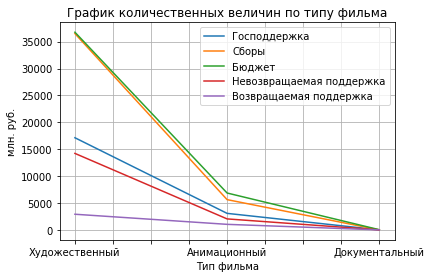

In [75]:
pivot_group(data_support, 'type', pl=True, x='Тип фильма', title='График количественных величин по типу фильма')

Гос поддержку получили фильмы жанров Художественный, Анимационный и документальный. Максимальные сборы и бюджет показали художественные фильмы. Общие сборы 36 490 216 425, общий бюджет 36 745 811 522, общая господдержка 17 127 198 847, средняя доля господдержки 55%.

#### Изучим студии фильмов с господдержкой

In [76]:
pivot_group(data_support, 'film_studio', head=10)

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
film_studio,,,,,,,
"ООО""Студия""ТРИТЭ""НикитыМихалкова""","842,104,482.00","4,181,941,534.00","1,225,476,058.00","792,104,482.00","50,000,000.00",0.69,3.46
"ООО""МЕМ-МЕДИА""позаказуАО""ВБДГруп""","60,000,000.00","3,073,568,690.79","160,000,000.00","35,000,000.00","25,000,000.00",0.38,19.21
"ООО""Студияанимационногокино""Мельница""","630,000,000.00","2,890,370,003.22","1,512,454,214.00","365,000,000.00","265,000,000.00",0.41,2.20
"ООО""ТаББаК""","744,000,000.00","2,787,109,356.67","1,175,888,584.00","564,000,000.00","180,000,000.00",0.63,2.50
"ООО""КинокомпанияМАРС-фильм""позаказуООО""ММЕ"",ООО""АмедиаПродакшн""иАО""Телекомпания""","180,000,000.00","2,271,754,004.52","563,784,717.00","120,000,000.00","60,000,000.00",0.32,4.03
"ООО""Киностудия""Слово""позаказуООО""УолтДиснейКомпанииСНГ"",АО""ВБДГруп""","100,000,000.00","1,655,037,688.00","352,477,575.00","50,000,000.00","50,000,000.00",0.28,4.70
"ООО""Водород2011"",ООО""АртПикчерсСтудия"",Государственнаятелевизионнаякомпания""Телеканал""Россия""-филиалфедеральногогосударственногоунитарногопредприятия""Всероссийскаягосударственнаятелевизионнаяирадиовещательнаякомпания""","85,000,000.00","1,445,731,797.89","148,585,222.00","60,000,000.00","25,000,000.00",0.57,9.73
"ООО""Водород2011"",ООО""АртПикчерсСтудия""","250,000,000.00","1,038,321,489.00","250,000,000.00","250,000,000.00",0.00,1.00,4.15
"ООО""ДКинтертеймент"",ООО""Киностудия""Слово"",ООО""Студия""ТРИТЭ""НикитыМихалкова""","260,000,000.00","820,528,005.21","390,191,139.00","260,000,000.00",0.00,0.67,2.10


Замечено много одинаковых студий с небольшими различиями в наименованиях или в формате "аббревиатура/полное название"

#### Изучим рейтинг фильмов с господдержкой

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
ratings_category,,,,,,,
9.00,"14,700,000.00","1,136,120.00","54,462,464.00","14,700,000.00",0.00,0.29,0.03
8.00,"566,846,881.00","887,167,049.00","956,211,601.00","499,500,000.00","67,346,881.00",0.49,0.59
7.00,"3,438,713,537.00","9,177,396,123.75","7,474,409,165.00","2,878,713,537.00","560,000,000.00",0.52,0.71
6.00,"8,160,196,569.00","20,055,647,264.65","17,505,697,516.00","6,574,043,450.00","1,586,153,119.00",0.53,0.95
5.00,"4,712,637,945.00","6,800,524,830.24","11,287,168,513.00","3,771,137,945.00","941,500,000.00",0.56,0.67
4.00,"1,768,500,000.00","2,671,131,222.03","3,144,674,187.00","1,279,500,000.00","489,000,000.00",0.59,0.86
3.00,"605,000,000.00","573,673,169.30","1,587,860,596.00","415,000,000.00","190,000,000.00",0.41,0.44
2.00,"220,123,915.00","457,761,423.17","503,804,174.00","185,123,915.00","35,000,000.00",0.49,0.68
1.00,"25,000,000.00","7,323,648.00","36,016,269.00","25,000,000.00",0.00,0.69,0.20


<AxesSubplot:title={'center':'График количественных величин по рейтингу'}, xlabel='Рейтинг', ylabel='млн. руб.'>

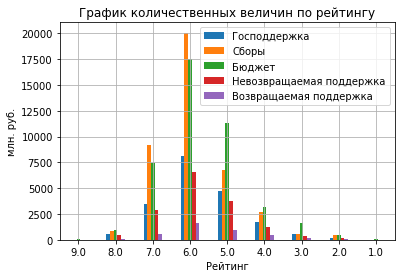

In [79]:
pivot_group(data_support, 'ratings_category', pl=True, x='Рейтинг', kn='bar',sort='ratings_category',
            title='График количественных величин по рейтингу')

Данные по рейтингу показывают, большинство фильмов с высоким сборами имеют рейтинг от 5 до 7. При этом на рейтинге 5 фильмы менее окупаемы

#### Изучим данные по стране-производителе

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
production_country,,,,,,,
Россия,"18,850,676,013.00","40,922,374,829.27","37,811,147,652.00","15,211,676,013.00","3,639,000,000.00",0.56,0.82
Россия-Украина,"27,510,000.00","401,804,461.90","131,000,000.00","27,510,000.00",0.00,0.21,3.07
Россия-Китай,"270,000,000.00","333,597,059.59","2,305,074,303.00","90,000,000.00","180,000,000.00",0.12,0.14
"Россия,Сербия","35,000,000.00","307,650,644.24","150,000,000.00","35,000,000.00",0.00,0.23,2.05
"Россия,Италия","120,000,000.00","54,387,242.71","919,299,176.00","120,000,000.00",0.00,0.25,0.04


<AxesSubplot:title={'center':'График количественных величин по стране-производителю'}, xlabel='Страна-производитель', ylabel='млн. руб.'>

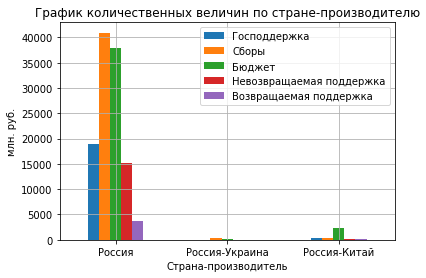

In [80]:
pivot_group(data_support, 'production_country', 5, pl=True, kn='bar',lc=3, x='Страна-производитель', 
            title='График количественных величин по стране-производителю')

In [81]:
data_support[data_support['production_country'] == 'США']

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,ratings,genres,box_office,show_start_date_year,director_main,genres_main,state_support_part,ratings_category,all_support,сoefficient_profit
1144,Вторжение,124002417,2017-08-01 12:00:00,Анимационный,БаобабСтудиос,США,ЭрикДарнелл,"Ф.Бондарчук,М.Врубель,А.Андрющенко,Д.Рудовский",«6+» - для детей старше 6 лет,"100,000,000.00",...,5.70,"фантастика,боевик",0.00,2017,ЭрикДарнелл,фантастика,0.53,5.00,"500,000,000.00",0.00


Данные по стране производителю показывают, что основная поддержка фильмов осуществялась в соновном только для "чисто" российских фильмов. Общие сборы 40 922 374 829, общий бюджет 37 811 147 652, общая господдержка 18 850 676 013, средняя доля господдержки 56%.

#### Изучим данные по возрастным ограничениям

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
age_restriction,,,,,,,
«12+» - для детей старше 12 лет,"7,299,394,165.00","19,957,963,755.94","14,643,946,009.00","5,831,894,165.00","1,467,500,000.00",0.53,1.02
«6+» - для детей старше 6 лет,"6,046,373,947.00","13,383,991,699.26","13,933,875,719.00","4,487,373,947.00","1,559,000,000.00",0.53,0.89
«16+» - для детей старше 16 лет,"5,569,053,319.00","7,658,462,636.93","11,841,591,936.00","4,733,900,200.00","835,153,119.00",0.57,0.70
«18+» - запрещено для детей,"1,012,346,881.00","560,158,730.15","2,309,837,155.00","980,000,000.00","32,346,881.00",0.53,0.24
«0+» - для любой зрительской аудитории,"273,520,000.00","552,932,752.50","902,984,585.00","228,520,000.00","45,000,000.00",0.40,0.28


<AxesSubplot:title={'center':'График количественных величин по возрастным ограничениям'}, xlabel='Возрастное ограничение', ylabel='млн. руб.'>

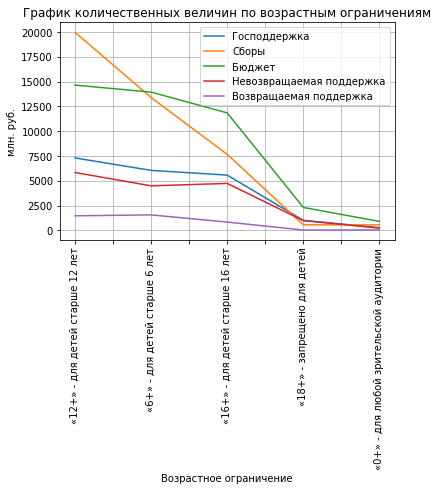

In [82]:
pivot_group(data_support, 'age_restriction', pl=True, rt=90, x='Возрастное ограничение', 
            title='График количественных величин по возрастным ограничениям')

Данные по возрастным ограничениям показывают, что поддержка фильмов осуществялась в основном для категорий 12+, 6+, 16+. При этом лучшие результаты показали фильмы с рейтингом 12+ (Общие сборы 19 957 963 755, общий бюджет 14 643 946 009, общая господдержка 7 299 394 165, средняя доля господдержки 53%).

#### Изучим данные по источнику финансирования

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
financing_source,,,,,,,
Фондкино,"14,178,595,958.00","35,986,152,828.59","29,507,722,037.00","10,565,095,958.00","3,613,500,000.00",0.55,1.34
Министерствокультуры,"4,836,661,000.00","5,322,018,327.93","11,475,203,758.00","4,836,661,000.00",0.00,0.53,0.39
"Министерствокультуры,Фондкино","1,185,431,354.00","805,338,418.26","2,649,309,609.00","859,931,354.00","325,500,000.00",0.56,0.18


<AxesSubplot:title={'center':'Диаграмма количественных величин по источнику финансирования'}, xlabel='Источник финансирования', ylabel='млн. руб.'>

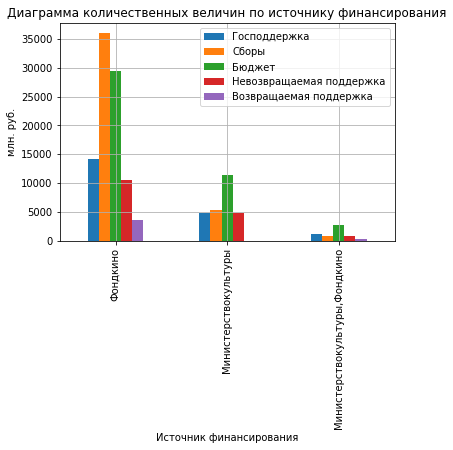

In [83]:
pivot_group(data_support, 'financing_source', pl=True, kn='bar', rt=90, x='Источник финансирования', 
            title='Диаграмма количественных величин по источнику финансирования')

Данные по источнику финансирования показывают, что поддержка фильмов осуществялась в основном "Фонда кино" (Общие сборы 35 986 152 828, общий бюджет 29 507 722 037, общая господдержка 14 178 595 958, средняя доля господдержки 55%).

#### Изучим данные по главным жанрам

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
genres_main,,,,,,,
комедия,"3,218,282,945.00","12,479,977,454.33","6,150,586,880.00","2,421,782,945.00","796,500,000.00",0.57,1.52
драма,"5,314,406,632.00","9,490,844,101.04","11,126,886,688.00","4,686,059,751.00","628,346,881.00",0.55,0.44
мультфильм,"2,461,520,000.00","5,622,014,134.66","5,815,499,467.00","1,531,520,000.00","930,000,000.00",0.50,1.00
спорт,"455,000,000.00","2,967,768,387.44","710,468,965.00","455,000,000.00",0.00,0.54,2.41
фантастика,"1,406,000,000.00","1,718,204,279.39","2,443,100,815.00","1,216,000,000.00","190,000,000.00",0.49,0.69


<AxesSubplot:title={'center':'Диаграмма количественных величин по жанрам'}, xlabel='Главный жанр', ylabel='млн. руб.'>

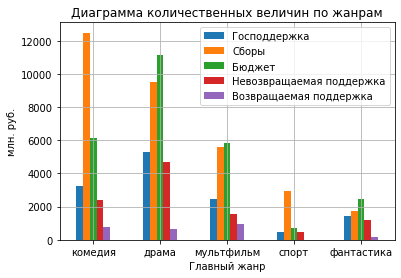

In [84]:
pivot_group(data_support, 'genres_main', 5, pl=True, kn='bar', lc=5, x='Главный жанр', 
            title='Диаграмма количественных величин по жанрам')

Данные по возрастным ограничениям показывают, что самые большие сборы были в основном для четырех жанров: комедия, драма, мультфильм, спорт. При этом лучшие результаты показали фильмы жанра комедия (Общие сборы 12 479 977 454, общий бюджет 6 150 586 880, общая господдержка 3 218 282 945, средняя доля господдержки 57%, окупаемость 1,52). При этом лучшая окупаемость у жанра Спорт, 2,41.

#### Изучим данные по главному режиссеру

In [85]:
pivot_group(data_support, 'director_main', 5)

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
director_main,,,,,,,
К.Шипенко,"312,000,000.00","3,827,772,217.79","704,930,668.00","287,000,000.00","25,000,000.00",0.45,6.92
А.Мегердичев,"400,000,000.00","2,779,686,144.00","590,192,191.00","400,000,000.00",0.00,0.68,4.71
Д.Дьяченко,"351,000,000.00","2,404,898,634.12","780,695,312.00","180,000,000.00","171,000,000.00",0.51,2.59
А.Сидоров,"180,000,000.00","2,271,754,004.52","563,784,717.00","120,000,000.00","60,000,000.00",0.32,4.03
О.Трофим,"85,000,000.00","1,445,731,797.89","148,585,222.00","60,000,000.00","25,000,000.00",0.57,9.73


#### Изучим данные по году выпуска

,Господдержка,Сборы,Бюджет,Невозвращаемая поддержка,Возвращаемая поддержка,Доля господдержки,Окупаемость
show_start_date_year,,,,,,,
2017,"3,683,971,662.00","10,865,075,300.96","8,001,172,568.00","2,864,624,781.00","819,346,881.00",0.51,0.96
2018,"3,446,969,465.00","9,934,069,010.25","7,000,664,099.00","2,784,969,465.00","662,000,000.00",0.54,1.16
2019,"4,379,000,000.00","8,406,446,236.63","11,703,866,609.00","3,556,000,000.00","823,000,000.00",0.51,0.77
2016,"4,303,155,482.00","6,081,707,839.10","7,554,942,748.00","3,381,655,482.00","921,500,000.00",0.57,0.69
2015,"3,656,241,459.00","5,785,285,418.14","7,738,669,207.00","3,019,088,340.00","637,153,119.00",0.56,0.61
2014,"597,002,299.00","1,020,603,384.60","1,377,484,783.00","521,002,299.00","76,000,000.00",0.54,0.58
2013,"134,347,945.00","20,322,385.10","255,435,390.00","134,347,945.00",0.00,0.47,0.06


<AxesSubplot:title={'center':'Диаграмма количественных величин по годам'}, xlabel='Год показа', ylabel='млн. руб.'>

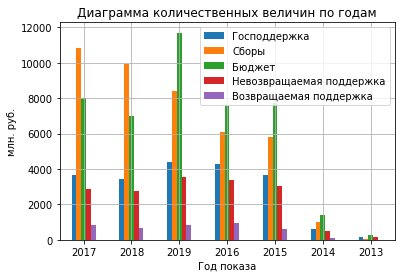

In [86]:
pivot_group(data_support, 'show_start_date_year', pl=True, kn='bar', x='Год показа', 
            title='Диаграмма количественных величин по годам')

Ситуация обратна мировым показам. 2017 год обогнал по сборам(Общие сборы 10 865 075 300, общий бюджет 8 001 172 568, общая господдержка 3 683 971 662, средняя доля господдержки 51%, окупаемость 0,96). При этом лучшая окупаемость в 2018 году - 1,16.

#### Изучим корреляцию количественных значений

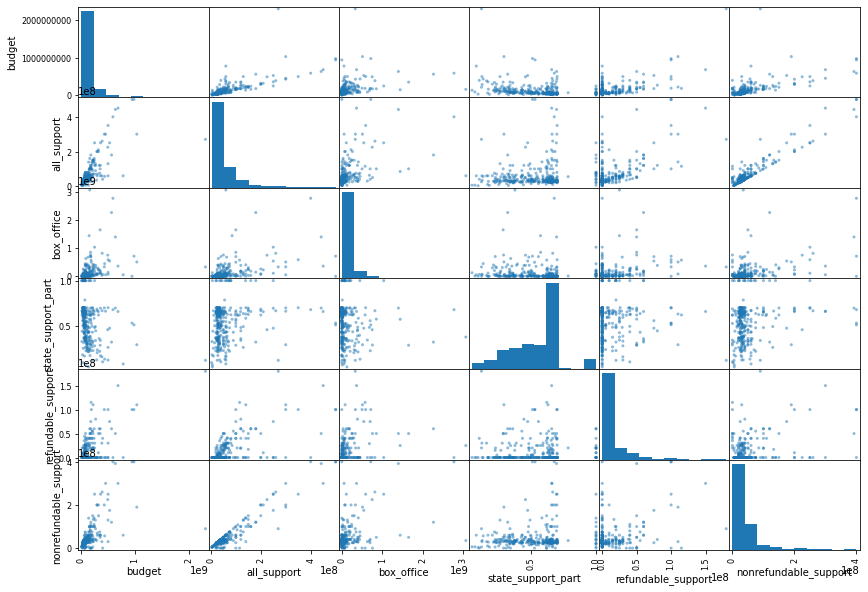

In [87]:
pd.plotting.scatter_matrix(data_support[['budget','all_support','box_office','state_support_part','refundable_support','nonrefundable_support']], figsize=(14,10));

Корреляция сборов с бюджетом

In [88]:
data_support['box_office'].corr(data_support['budget'])

0.3633109338505858

Сборы показывают положительную среднюю корреляцию с бюджетом - 0,36

Корреляция сборов с рейтингом

In [94]:
data_support['box_office'].corr(data_support['ratings'])

0.1410905179321342

Корреляция сборов с господдержкой

In [89]:
data_support['box_office'].corr(data_support['all_support'])

0.45632186146154785

Сборы показывают положительную среднюю корреляцию с поддержкой - 0,45

Корреляция сборов с долей господдержки

In [90]:
data_support['box_office'].corr(data_support['state_support_part'])

-0.08194785482977199

Сборы непоказывают корреляцию с долей поддержки

Корреляция бюджета с господдержкой

In [91]:
data_support['budget'].corr(data_support['all_support'])

0.7362498101950297

Бюджет показывают высокую положительную корреляцию с поддержкой - 0,73

Корреляция бюджета с долей господдержки

In [92]:
data_support['budget'].corr(data_support['state_support_part'])

-0.28301981801335974

Бюджет показывают слабую отрицательную корреляцию с поддержкой - -0,28

### Шаг 5. Напишите общий вывод

В ходе анализа российского кинопроката были сделаны выводы:
1. Больше всего фильмов вышло в 2019 году - 523 фильма, меньше всего в 2010, 2011 - по 107 фильма. Наиболее полно представлен 2016 год, в котором вышло 502 фильма.
2. С 2014 года наблюдается резкое увеличение сборов. При этом минимальная сумма сборов в 2012 году - 7,003,393.0, а максимальная сумма сборов в 2018 году - 49,654,129,655.82. Данное наблюдение могло возникнуть из-за изменения курса валюты в 2014 году и более качественного сбора информации о прокате.
3. Максимальная средняя сумма сборов в 2017 году - 98 697 220, медиана - 3 044 403
4. Возрастное ограничение аудитории влияет на сборы фильма в прокате. Наиболее кассовыми являются фильмы с рейтингом 6+, а наименее кассовыми с рейтингом 0+. В зависимости от года картина по показателям для разных ограниченийсущественно не изменяется, но изменяется общая сумма кассовых сборов.

В ходе анализа российского кинопроката для фильмов с господдержкрй были сделаны выводы:
1. Гос поддержку получили фильмы жанров Художественный, Анимационный и документальный. Максимальные сборы и бюджет показали художественные фильмы. Общие сборы 36 490 216 425, общий бюджет 36 745 811 522, общая господдержка 17 127 198 847, средняя доля господдержки 55%.
2. Данные по рейтингу показывают, большинство фильмов с высоким сборами имеют рейтинг от 5 до 7. При этом на рейтинге 5 фильмы менее окупаемы
3. Данные по стране производителю показывают, что основная поддержка фильмов осуществялась в соновном только для "чисто" российских фильмов. Общие сборы 40 922 374 829, общий бюджет 37 811 147 652, общая господдержка 18 850 676 013, средняя доля господдержки 56%.
4. Данные по возрастным ограничениям показывают, что поддержка фильмов осуществялась в основном для категорий 12+, 6+, 16+. При этом лучшие результаты показали фильмы с рейтингом 12+ (Общие сборы 19 957 963 755, общий бюджет 14 643 946 009, общая господдержка 7 299 394 165, средняя доля господдержки 53%).
5. Данные по источнику финансирования показывают, что поддержка фильмов осуществялась в основном "Фонда кино" (Общие сборы 35 986 152 828, общий бюджет 29 507 722 037, общая господдержка 14 178 595 958, средняя доля господдержки 55%).
6. Данные по возрастным ограничениям показывают, что самые большие сборы были в основном для четырех жанров: комедия, драма, мультфильм, спорт. При этом лучшие результаты показали фильмы жанра комедия (Общие сборы 12 479 977 454, общий бюджет 6 150 586 880, общая господдержка 3 218 282 945, средняя доля господдержки 57%, окупаемость 1,52). При этом лучшая окупаемость у жанра Спорт - 2,41.
7. Ситуация обратна мировым показам. 2017 год обогнал по сборам(Общие сборы 10 865 075 300, общий бюджет 8 001 172 568, общая господдержка 3 683 971 662, средняя доля господдержки 51%, окупаемость 0,96). При этом лучшая окупаемость в 2018 году - 1,16.
8. Сборы показывают положительную среднюю корреляцию с бюджетом - 0,36
Сборы показывают положительную слабую корреляцию с рейтингом - 0,14
Сборы показывают положительную среднюю корреляцию с поддержкой - 0,45
Бюджет показывают высокую положительную корреляцию с поддержкой - 0,73
Бюджет показывают слабую отрицательную корреляцию с поддержкой - 0,28

Как показывают данные, фильмы с господдержекой могут быть интересны зрителю, но если учитывать современные тренды по жанру и возрастным ограничениям.